# Elastic Net Model
## Timepoints T1-T2

In [1]:
import sys, os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
import model_elasticnet
from sklearn.preprocessing import PowerTransformer
os.environ['PYTHONWARNINGS'] = 'ignore'
MODEL_DIR = os.path.abspath('../models')


In [3]:
# Running through preprocessing steps
# Load raw data
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)

# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)

print(f"df_im_mod : {df_im_mod.shape}")
print(f"df_cl_mod : {df_cl_mod.shape}")


df_im_mod : (814, 77)
df_cl_mod : (842, 26)


In [4]:
# Constructing targets:
print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1, 2])
targets_under_load = model.construct_datasets_targets(df_cl_mod, 'pain_under_load', [1, 2])


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=1.347  std=2.051  [-4.000, 7.100]
    pain_reduction_pct                          mean=19.196  std=32.847  [-100.000, 87.654]

  Target distributions:
    pain_under_load_reduction                   mean=0.551  std=0.753  [-1.000, 3.000]
    pain_under_load_reduction_pct               mean=14.125  std=20.231  [-50.000, 75.000]


## Dataset Overview

In [ ]:
print('\nConstructing datasets for modeling:')
# Construct model datasets for each target type:
_unique_targets = {
    'pain_reduction':            pain_targets,
    'pain_under_load_reduction': targets_under_load,
}

model_datasets = {}
for tgt, tdf in _unique_targets.items():
    model_datasets[tgt] = model.create_model_datasets(
        df_im_mod, df_cl_mod, tdf, timepoints=[1, 2])                   # df im first
model_datasets['pain_reduction_pct'] = model_datasets['pain_reduction']



Constructing datasets for modeling:

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_scale_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (116, 95), Number of Patients: 116

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_under_load_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (115, 95), Number of Patients: 115


## Elasticnet with MRMR feature selection and Optuna Hyperparameter Tuning

## Target: pain_reduction 

In [7]:
import model_elasticnet
pt = PowerTransformer(method='yeo-johnson', standardize=True)

en_mrmr_results_df, en_feature_freq = model_elasticnet.elasticnet_mrmr(
        model_datasets['pain_reduction'],
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save results and feature frequency list
joblib.dump(en_mrmr_results_df,      os.path.join(MODEL_DIR, 'en_results_df.pkl'))
joblib.dump(en_feature_freq,         os.path.join(MODEL_DIR, 'en_feature_freq.pkl'))



 Nested CV - ElasticNet + MRMR + Optuna — pain_reduction_pct
  n=116, p=92
  Outer 4×5=20   Inner 4×5=20   Optuna trials Model =50   Optuna trials MRMR =20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  Best MRMR params: {'K': 10, 'n_estimators': 200, 'max_depth': 2, 'min_samples_leaf': 3}  RMSE=1.2205
  10 selected features: ['Monocytes_t2_minus_t1', 'Mo1_t2_minus_t1', 'TH_CD25+_t2_minus_t1', 'T_CD25hi_t2_minus_t1', 'TC_PD1+_t2_minus_t1', 'TC CM_PD1+_t2_minus_t1', 'NLR_t2_minus_t1', 'age_at_start', 'weight_kg', 'height_cm']
    Trial   1/50: RMSE=1.0017  {'alpha': 2.2201994611007723, 'l1_ratio': 0.6616390218862037}
    Trial   2/50: RMSE=1.0063  {'alpha': 0.0028274146600990036, 'l1_ratio': 0.7483385373668919}
    Trial   3/50: RMSE=0.9729  {'alpha': 0.15200197868556872, 'l1_ratio': 0.4576207240364979}
    Trial   4/50: RMSE=0.9832  {'alpha': 0.0750241073352577, 'l1_ratio': 0.4949

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\en_feature_freq.pkl']

## Plot of Feature Frequency List 
### Selected features across all outer folds

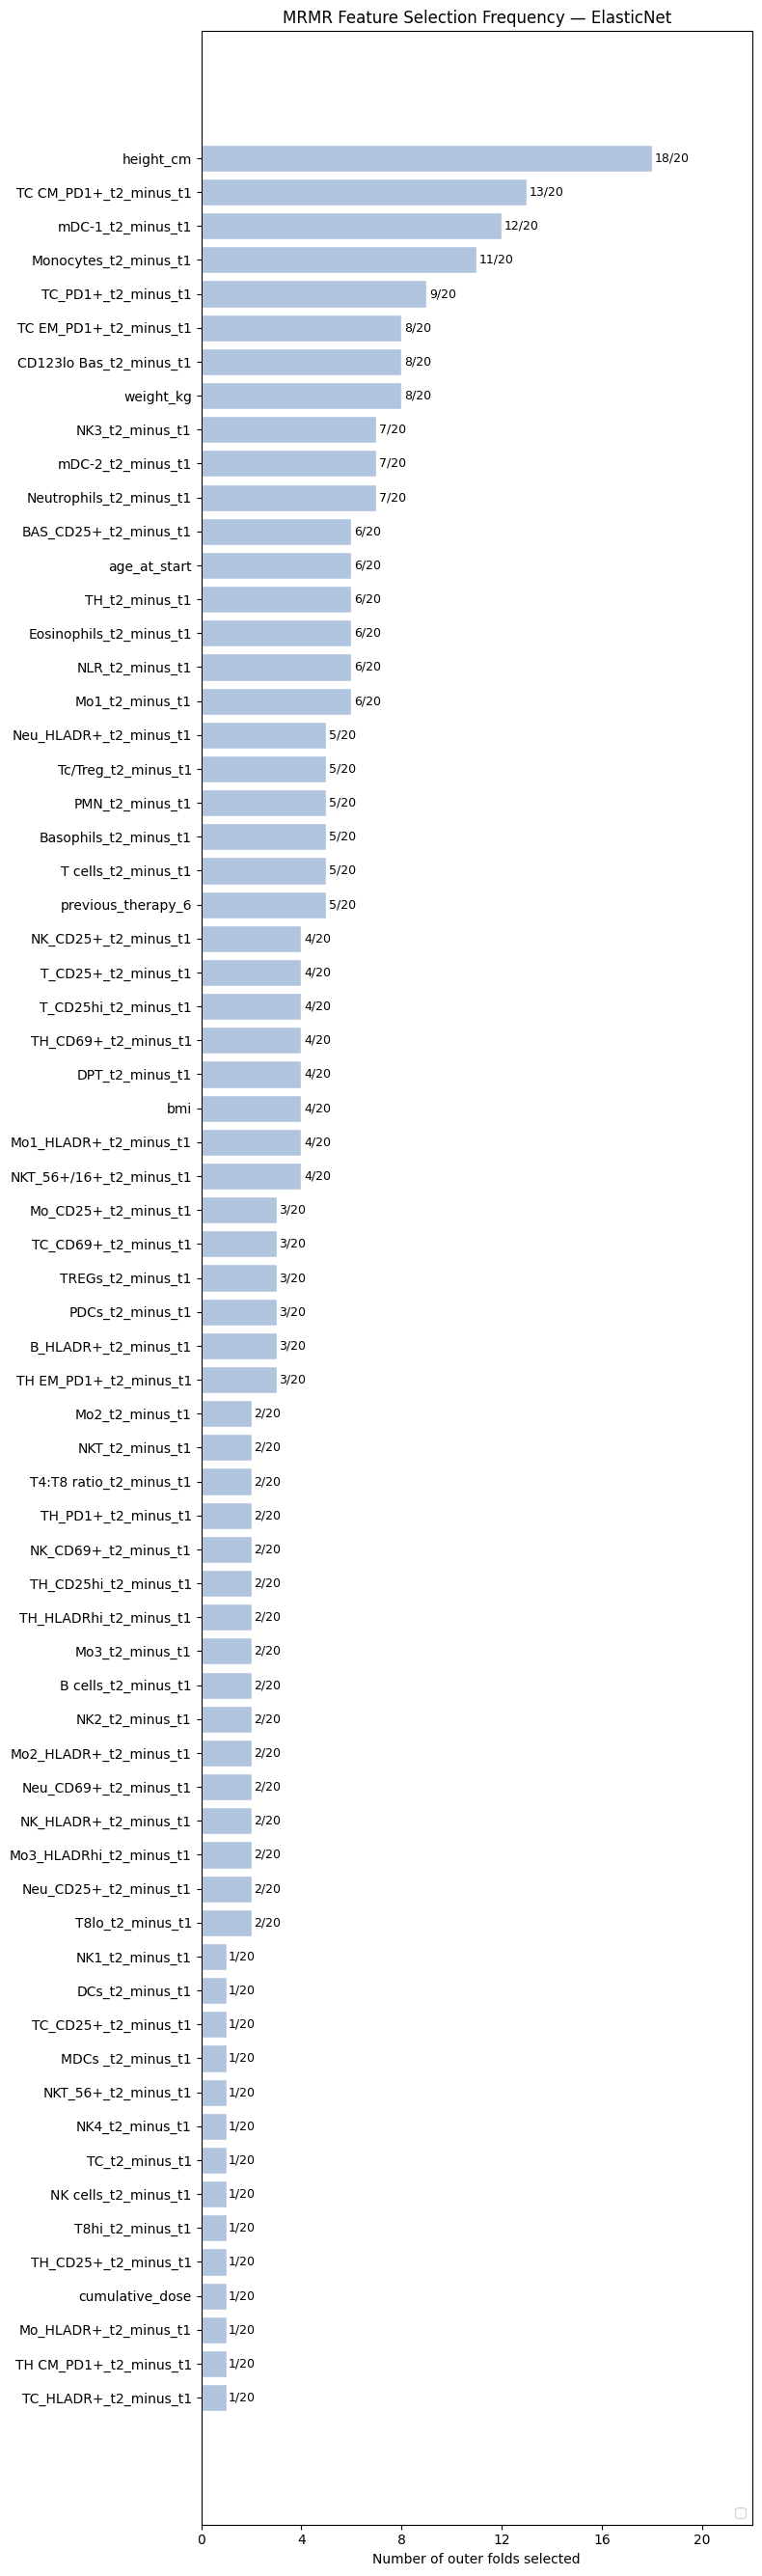

In [8]:
en_feature_frequencies = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq.pkl'))
model.plot_feature_frequency(en_feature_frequencies, name='ElasticNet')

# Elasticnet on thresholds

In [ ]:
en_sweep_df = model_elasticnet.elasticnet_threshold_analysis(
     model_datasets['pain_reduction'], 
     en_feature_frequencies, 
     target_col='pain_reduction_pct',
     random_state=42, 
     target_transformer=pt)

joblib.dump(en_sweep_df,      os.path.join(MODEL_DIR, 'en_sweep_df.pkl'))

# Plot performances on different feature-tresholds
model.plot_sweep(en_sweep_df, name='ElasticNet: Performance Metrics vs. n Features')

## Final Elasticnet model on selected features

In [ ]:
en_feature_freq = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq'))
import model_elasticnet
# selecting features in more than ../20 outer folds:
# sel_features = 

en_model, en_X_final, en_y_pred, en_patient_err, en_scaler = model_elasticnet.run_tuned_elasticnet(
    model_datasets['pain_reduction'], 
    sel_features,
    target_col='pain_reduction', 
    random_state=42,
    target_transformer=pt)

# save results
joblib.dump(en_model,                os.path.join(MODEL_DIR, 'en_model.pkl'))
joblib.dump(en_X_final,              os.path.join(MODEL_DIR, 'en_X_final_df.pkl'))
joblib.dump(en_patient_err,          os.path.join(MODEL_DIR, 'en_patient_err.pkl'))
joblib.dump(en_scaler,               os.path.join(MODEL_DIR, 'en_scaler.pkl'))



1.2: CatBoost (Nested CV + RENT + Optuna) — pain_reduction_pct (T1-T2)

  CatBoost + Optuna + RENT — pain_reduction_pct
  n=117, p=91, τ₃=0.95
  Outer 4×5=20 | Inner 4×5=20 | RENT & Optuna trials=20 | K=100

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  Best RENT RMSE: 0.9869 Best Parameters: {'C': 1.2330416234654664, 'l1_ratio': 0.1420456273678036, 'tau_1': 0.7479176522860225, 'tau_2': 0.9353882346481023}
  RENT Selected: 91/91 features — ['PMN_t2_minus_t1', 'Neutrophils_t2_minus_t1', 'Eosinophils_t2_minus_t1', 'Basophils_t2_minus_t1', 'CD123lo Bas_t2_minus_t1', 'Monocytes_t2_minus_t1', 'T cells_t2_minus_t1', 'TH_t2_minus_t1']...
    Trial   1/20: RMSE=1.0031  {'depth': 10, 'learning_rate': 0.0575889323094765, 'l2_leaf_reg': 1.229981986421865, 'bagging_temperature': 0.35772697537576714}
    Trial   2/20: RMSE=0.9978  {'depth': 3, 'learning_rate': 0.0013893975468350828, 'l2_leaf_r

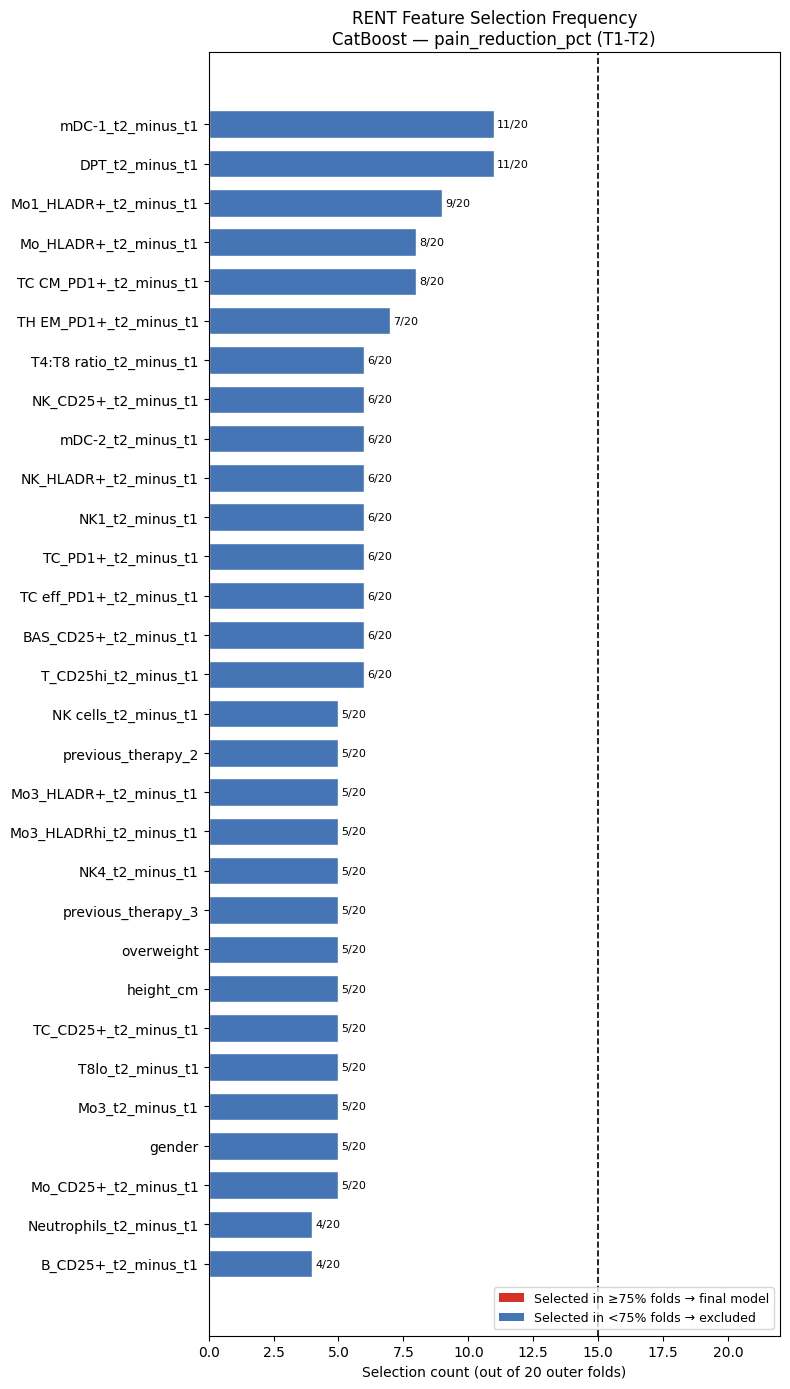


SHAP — CatBoost (pain_reduction_pct, T1-T2)

=== SHAP Analysis: CatBoost — pain_reduction_pct (T1-T2) ===


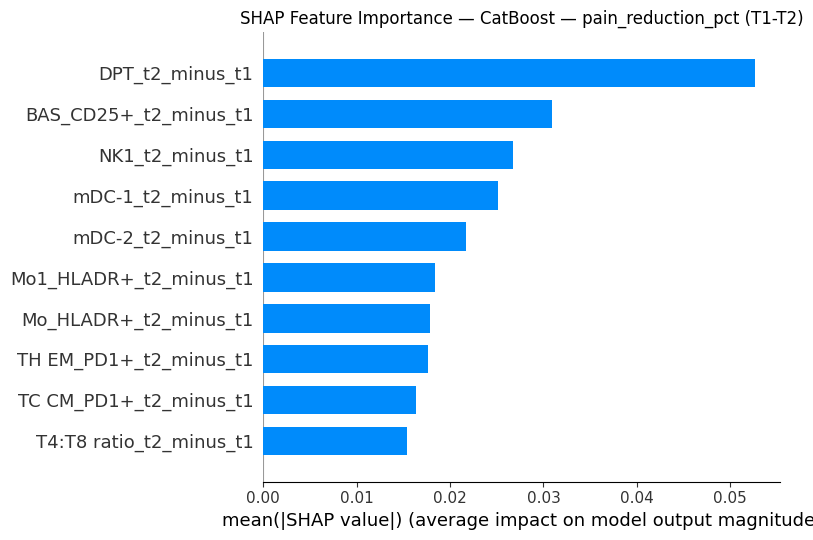

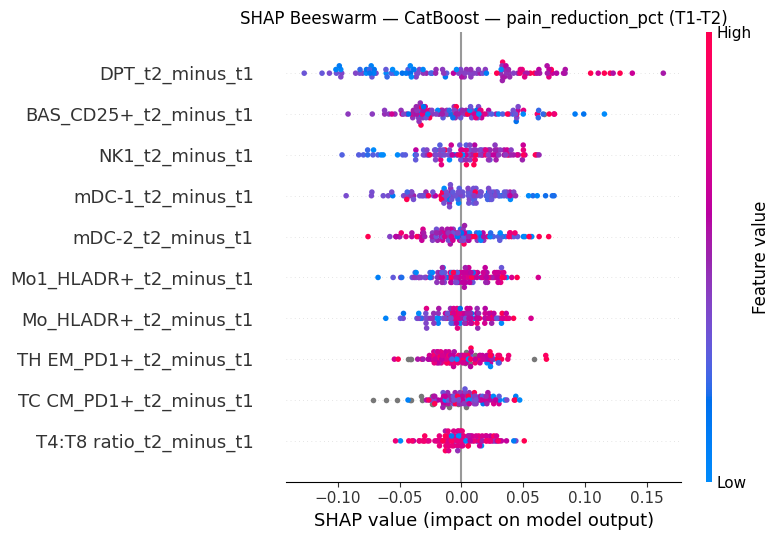

In [ ]:
cb_pct_model = CatBoostRegressor()
cb_pct_model.load_model(os.path.join(MODEL_DIR, 'cb_pct_model.cbm'))
cb_pct_X = joblib.load(os.path.join(MODEL_DIR, 'cb_pct_X.pkl'))

# SHAP plot on saved model
print('\nSHAP — CatBoost (pain_reduction_pct, T1-T2)')
cb_pct_shap = model.plot_shap_regressor(
    cb_pct_model, cb_pct_X, 'CatBoost — pain_reduction_pct (T1-T2)')
